This notebook performs exploratory data analysis (EDA) on a financial transactions dataset
to understand structure, distributions, and fraud patterns before modeling.

### 1. Data Loading

In [14]:
# Where started
import os
print(os.name)

posix


In [2]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("EDA") \
    .master("local[*]") \
    .getOrCreate()

df = spark.read.csv("../data/raw/*.csv", header=True, inferSchema=True)

df.printSchema()
df.show(5)

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/26 12:19:43 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
                                                                                

root
 |-- step: integer (nullable = true)
 |-- type: string (nullable = true)
 |-- amount: double (nullable = true)
 |-- nameOrig: string (nullable = true)
 |-- oldbalanceOrg: double (nullable = true)
 |-- newbalanceOrig: double (nullable = true)
 |-- nameDest: string (nullable = true)
 |-- oldbalanceDest: double (nullable = true)
 |-- newbalanceDest: double (nullable = true)
 |-- isFraud: integer (nullable = true)
 |-- isFlaggedFraud: integer (nullable = true)

+----+--------+--------+-----------+-------------+--------------+-----------+--------------+--------------+-------+--------------+
|step|    type|  amount|   nameOrig|oldbalanceOrg|newbalanceOrig|   nameDest|oldbalanceDest|newbalanceDest|isFraud|isFlaggedFraud|
+----+--------+--------+-----------+-------------+--------------+-----------+--------------+--------------+-------+--------------+
|   1| PAYMENT| 9839.64|C1231006815|     170136.0|     160296.36|M1979787155|           0.0|           0.0|      0|             0|
|   1| PA

### 2. Basic Info

In [3]:
print("Row count:", df.count())
print("Column count:", len(df.columns))

[Stage 3:===>                                                     (1 + 15) / 16]

Row count: 6362620
Column count: 11


### 3. Class Distribution

In [4]:
df.groupBy("isFraud").count().show()

[Stage 6:=============================>                            (8 + 8) / 16]

+-------+-------+
|isFraud|  count|
+-------+-------+
|      1|   8213|
|      0|6354407|
+-------+-------+



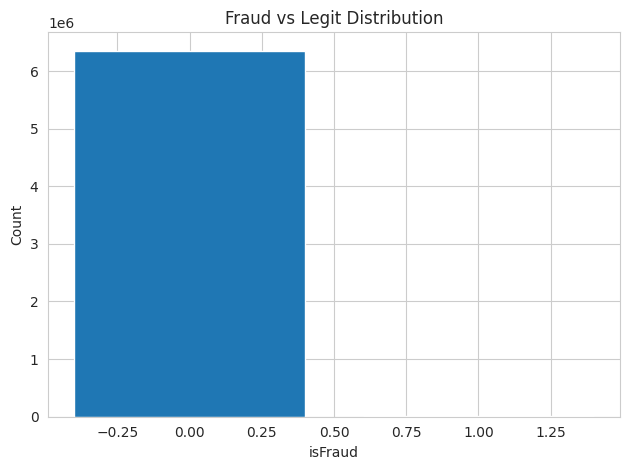

[Stage 35:>                                                       (0 + 16) / 16]

Fraud percentage: 0.1291%


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

pdf_fraud = df.groupBy("isFraud").count().toPandas()

pdf_fraud["percentage"] = pdf_fraud["count"] / pdf_fraud["count"].sum() * 100
pdf_fraud

plt.bar(pdf_fraud["isFraud"], pdf_fraud["count"])
plt.title("Fraud vs Legit Distribution")
plt.xlabel("isFraud")
plt.ylabel("Count")
plt.tight_layout()
plt.show()
plt.close()

fraud_count = df.filter("isFraud = 1").count()
total_count = df.count()

fraud_percentage = fraud_count / total_count * 100

print(f"Fraud percentage: {fraud_percentage:.4f}%")

The dataset is extremely imbalanced.

Fraud transactions represent approximately 0.13% of all observations.

Such imbalance may significantly impact model performance
and requires dedicated handling strategies (e.g., resampling or cost-sensitive learning).

### 4. Transaction Type Distribution

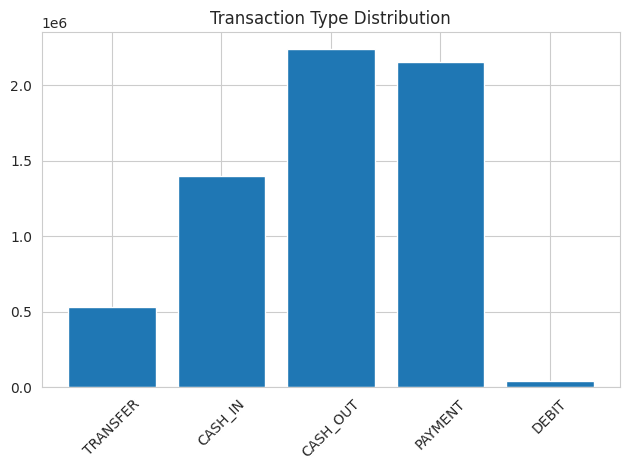

In [8]:
pdf_type = df.groupBy("type").count().toPandas()

plt.bar(pdf_type["type"], pdf_type["count"])
plt.title("Transaction Type Distribution")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.close()

CASH_OUT and PAYMENT transactions dominate the dataset.

However, frequency alone does not determine predictive power.
Further analysis of fraud distribution across transaction types is required.

### 5. Transaction Amount Distribution

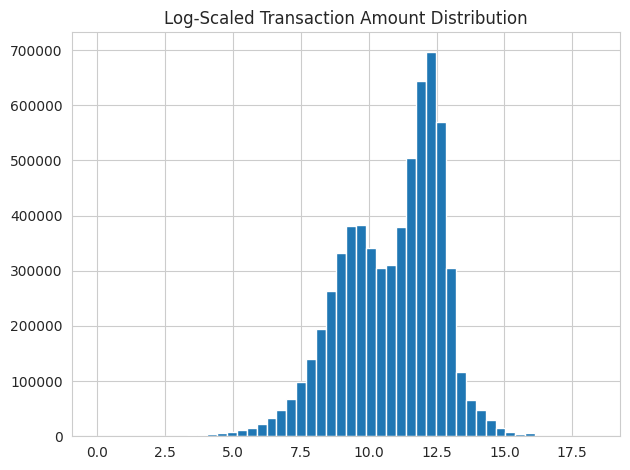

In [6]:
import numpy as np
pdf_amount = df.select("amount").toPandas()

plt.hist(np.log1p(pdf_amount["amount"]), bins=50)
plt.title("Log-Scaled Transaction Amount Distribution")
plt.tight_layout()
plt.show()
plt.close()

Transaction amounts are heavily right-skewed, with a long tail of large values.

This suggests:
- presence of outliers
- need for log transformation before modeling

### 6. Fraud vs Amount

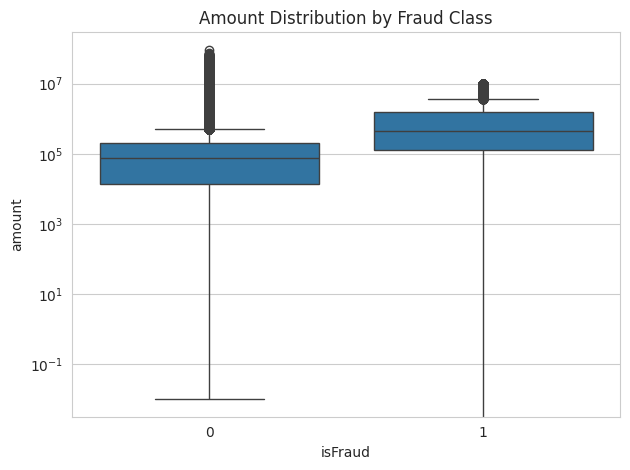

In [9]:
pdf_amount = df.select("amount", "isFraud").toPandas()

import seaborn as sns

sns.boxplot(x="isFraud", y="amount", data=pdf_amount)
plt.yscale("log")
plt.title("Amount Distribution by Fraud Class")
plt.tight_layout()
plt.show()
plt.close()

Fraudulent transactions tend to have higher median values compared to legitimate ones.

However, significant overlap exists between the distributions,
indicating that transaction amount alone is not sufficient for classification.

In [ ]:
### 7. Fraud vs type

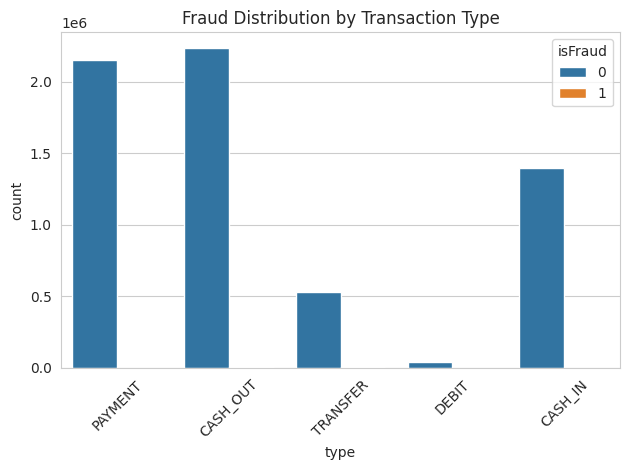

In [10]:
pdf_fraud_type = df.groupBy("type", "isFraud").count().toPandas()

import seaborn as sns

sns.barplot(data=pdf_fraud_type, x="type", y="count", hue="isFraud")
plt.title("Fraud Distribution by Transaction Type")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.close()

Fraud is concentrated almost exclusively in TRANSFER and CASH_OUT transaction types.

This indicates strong predictive potential of the transaction type feature,
especially for distinguishing fraudulent behavior.

In [ ]:
### 8. Null check

In [11]:
from pyspark.sql.functions import col, count, when

df.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in df.columns
]).show()

[Stage 23:===>                                                    (1 + 15) / 16]

+----+----+------+--------+-------------+--------------+--------+--------------+--------------+-------+--------------+
|step|type|amount|nameOrig|oldbalanceOrg|newbalanceOrig|nameDest|oldbalanceDest|newbalanceDest|isFraud|isFlaggedFraud|
+----+----+------+--------+-------------+--------------+--------+--------------+--------------+-------+--------------+
|   0|   0|     0|       0|            0|             0|       0|             0|             0|      0|             0|
+----+----+------+--------+-------------+--------------+--------+--------------+--------------+-------+--------------+



No missing values detected. Dataset is complete and does not require imputation.

## 9. Key Observations

- Dataset is highly imbalanced (~0.13% fraud cases)
- Fraud occurs primarily in TRANSFER and CASH_OUT transactions
- Transaction amounts are highly skewed (log transformation recommended)
- Fraudulent transactions tend to have higher median values
- No missing values detected

These findings suggest that:
- class imbalance handling will be necessary
- transaction type is a critical feature
- amount should be transformed before modeling